# Chapter 5:线性变换 (Linear Transformations)

在本章中，我们将线性代数从“静态”的向量空间带入了“动态”的变换世界。我们将通过代码探索以下核心概念：

- 线性变换的定义：验证加法与数乘的保持。

- 矩阵与基变换：理解相似矩阵如何在不同视角下描述同一运动。

- 特征值与特征向量：寻找变换中的“不动”轴。

- 凯莱-哈密顿定理：验证矩阵与其特征多项式的深层联系。

- 对角化：利用特征分解加速矩阵运算。

## 5.1 线性变换的定义与几何直观
线性变换是保持向量加法和标量乘法的映射。在几何上，这意味着网格线保持平行且等距，原点保持固定。

### 数值验证线性性
我们需要验证对于任意变换 $T(x) = Ax$，是否满足 $T(ax+by) = aT(x) + bT(y)$。

In [ ]:
# 验证线性变换的代数定义
import torch

def verify_linearity():
    # 1. 设置随机种子以保证结果可复现
    torch.manual_seed(42)

    # 2. 定义一个线性变换 T(x) = A @ x
    # 这里我们定义一个 2x3 的矩阵，将 3维空间映射到 2维空间
    A = torch.tensor([[2.0, -1.0, 0.0],
                      [1.0,  3.0, 4.0]])

    def T(x):
        return A @ x

    # 3. 随机生成向量 x, y 和标量 a, b
    x = torch.randn(3)
    y = torch.randn(3)
    a = torch.randn(()) # 标量
    b = torch.randn(()) # 标量

    # 4. 计算等式两边
    # LHS: 左边 = T(ax + by)
    lhs = T(a * x + b * y)
    
    # RHS: 右边 = aT(x) + bT(y)
    rhs = a * T(x) + b * T(y)

    # 5. 验证结果
    # 使用 torch.allclose 处理浮点数精度误差
    dist = torch.norm(lhs - rhs).item()
    is_linear = torch.allclose(lhs, rhs, atol=1e-6)

    print(f"LHS (T(ax+by)): {lhs}")
    print(f"RHS (aT(x)+bT(y)): {rhs}")
    print(f"差值范数: {dist}")
    print(f"验证线性性结论: {'通过' if is_linear else '失败'}")

verify_linearity()

LHS (T(ax+by)): tensor([0.1922, 6.1454])
RHS (aT(x)+bT(y)): tensor([0.1922, 6.1454])
差值范数: 0.0
验证线性性结论: 通过


### 可视化线性变换（网格变形）
线性变换最直观的理解是看它如何改变空间网格。我们将展示一个 2D 变换如何拉伸和旋转空间，同时保持“平行线依旧平行”。

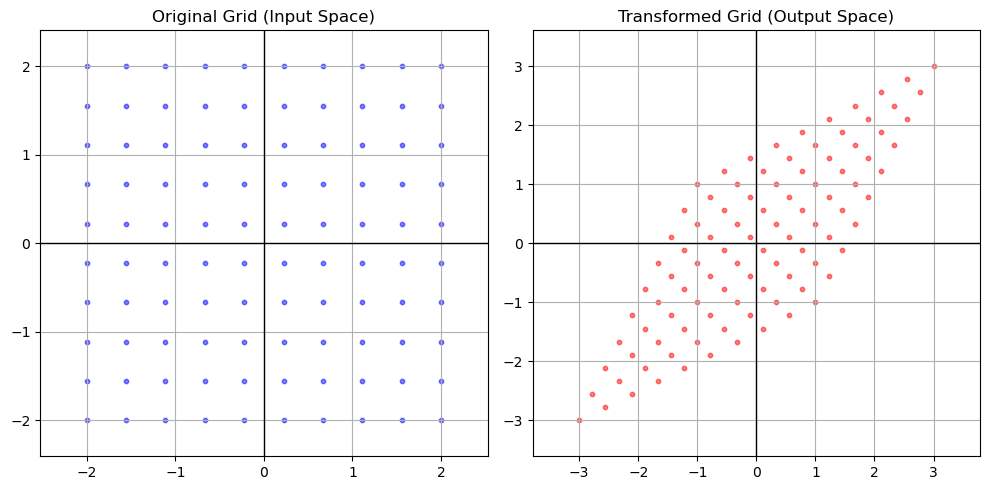

In [ ]:
# 可视化：线性变换对二维网格的影响
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_transform():
    # 1. 定义变换矩阵 (例如：剪切 + 缩放)
    # A = [[1, 0.5], [0, 1]] 是剪切矩阵
    A = torch.tensor([[1.0, 0.5], 
                      [0.5, 1.0]]) 

    # 2. 创建网格点
    # 在 -2 到 2 之间生成网格
    x = torch.linspace(-2, 2, 10)
    y = torch.linspace(-2, 2, 10)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    
    # 展平为点集 (2, N)
    points = torch.stack([X.flatten(), Y.flatten()])

    # 3. 应用变换 T(x) = Ax
    transformed_points = A @ points

    # 4. 绘图
    plt.figure(figsize=(10, 5))

    # 子图1：原始网格
    plt.subplot(1, 2, 1)
    plt.scatter(points[0], points[1], c='blue', s=10, alpha=0.5)
    plt.title("Original Grid (Input Space)")
    plt.grid(True)
    plt.axis('equal')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    # 子图2：变换后的网格
    plt.subplot(1, 2, 2)
    plt.scatter(transformed_points[0], transformed_points[1], c='red', s=10, alpha=0.5)
    plt.title("Transformed Grid (Output Space)")
    plt.grid(True)
    plt.axis('equal')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    plt.tight_layout()
    plt.show()

visualize_transform()

### 利用 SVD 寻找“核”与验证秩-零化度定理
书里提到核是“塌陷到原点的方向集合”。在 PyTorch 中，我们可以通过奇异值分解（SVD）来找到这些方向。对于矩阵 $A$，其 SVD 分解 $A=U\Sigma V^T$ 中，对应奇异值为 0 的那些 $V$ 的列向量，就构成了核空间的基。

In [11]:
# 秩-零化度定理验证与“核”空间的寻找
import torch
import torch.linalg as LA

def rank_nullity_demo():
    torch.manual_seed(42)
    print("=== 秩-零化度定理 (Rank-Nullity Theorem) 验证 ===")

    # 1. 构造一个“秩亏”矩阵 (Rank Deficient Matrix)
    # 我们构造一个 3x3 矩阵，但让第3列是第1、2列的线性组合
    # 这样它的秩应该是 2，而不是 3
    col1 = torch.tensor([1.0, 2.0, 3.0])
    col2 = torch.tensor([4.0, 5.0, 6.0])
    col3 = col1 + col2  # 线性相关
    
    A = torch.stack([col1, col2, col3], dim=1)
    
    # 2. 计算秩 (Rank)
    # PyTorch 使用 SVD 判定秩（奇异值大于阈值的个数）
    rank = LA.matrix_rank(A)
    n = A.shape[1]  # 输入空间维度 (3)
    
    print(f"矩阵 A:\n{A}")
    print(f"输入维度 (n): {n}")
    print(f"像空间维数 (Rank): {rank}")
    
    # 根据定理，零化度 (Nullity) 应该是 n - rank
    expected_nullity = n - rank
    print(f"预期核空间维数 (Nullity = n - Rank): {expected_nullity}")

    # 3. 寻找核空间 (Kernel/Null Space)
    # 利用 SVD: A = U S V^T
    # V 的最后 (n - rank) 列构成了核的一组基
    U, S, Vh = LA.svd(A)
    V = Vh.T # Vh 是 V 的转置
    
    print(f"奇异值 (Singular Values): {S}")
    # 注意：最后一个奇异值应该非常接近 0
    
    # 提取核向量 (对应最小奇异值的右奇异向量)
    # 因为 nullity = 1，我们取 V 的最后一列
    null_space_basis = V[:, rank:] 
    
    print(f"核空间的基向量 (Kernel Basis):\n{null_space_basis}")

    # 4. 验证核向量是否真的被映射为 0
    # result = A @ kernel_vector 应该接近 0
    mapping_result = A @ null_space_basis
    norm_result = torch.norm(mapping_result).item()
    
    print(f"||A @ kernel_vector||: {norm_result:.2e}")
    print(f"验证: 向量确实落入了核空间 (变换后消失)? {'是' if norm_result < 1e-5 else '否'}")

rank_nullity_demo()

=== 秩-零化度定理 (Rank-Nullity Theorem) 验证 ===
矩阵 A:
tensor([[1., 4., 5.],
        [2., 5., 7.],
        [3., 6., 9.]])
输入维度 (n): 3
像空间维数 (Rank): 2
预期核空间维数 (Nullity = n - Rank): 1
奇异值 (Singular Values): tensor([1.5663e+01, 8.1259e-01, 3.1065e-07])
核空间的基向量 (Kernel Basis):
tensor([[-0.5773],
        [-0.5774],
        [ 0.5774]])
||A @ kernel_vector||: 9.83e-07
验证: 向量确实落入了核空间 (变换后消失)? 是


## 5.2 矩阵表示与基变换
相似矩阵 $B = M^{-1}AM$ 本质上是同一个线性变换在不同“坐标系眼镜”下的快照。下面的代码将验证这一核心观点：无论我们在哪个基下计算，最终的物理结果（向量位置）应该是一致的。

### 模拟基变换与相似性验证

In [ ]:
# 验证相似矩阵描述同一变换
import torch
import torch.linalg as LA

def verify_similarity():
    torch.manual_seed(0)

    # 1. 定义旧基下的矩阵 A (标准基)
    A = torch.tensor([[2.0, 3.0],
                      [1.0, 4.0]])

    # 2. 定义新基矩阵 M (列向量为新基在旧基下的坐标)
    # M 必须是可逆的
    M = torch.tensor([[1.0, 1.0],
                      [1.0, 2.0]])
    
    # 计算 M 的逆
    M_inv = LA.inv(M)

    # 3. 计算新基下的矩阵 B = M^{-1} A M
    B = M_inv @ A @ M

    print(f"Matrix A (Old Basis):\n{A}")
    print(f"Matrix B (New Basis):\n{B}")

    # 4. 验证核心哲学：路径不影响终点
    # 路径1：直接在旧基下变换
    v_old = torch.tensor([2.0, 4.0]) # 一个向量在旧基下的坐标
    Tv_path1 = A @ v_old

    # 路径2：换到新基 -> 变换 -> 换回旧基
    v_new = M_inv @ v_old      # 1. 坐标变换：旧 -> 新
    Tv_new = B @ v_new         # 2. 在新世界做线性变换
    Tv_path2 = M @ Tv_new      # 3. 坐标变换：新 -> 旧

    # 5. 比较两条路径的结果
    diff = torch.norm(Tv_path1 - Tv_path2).item()
    print(f"\nPath 1 Result (A @ v): {Tv_path1}")
    print(f"Path 2 Result (M @ B @ M_inv @ v): {Tv_path2}")
    print(f"Consistency Check (Diff): {diff:.2e}")

verify_similarity()

Matrix A (Old Basis):
tensor([[2., 3.],
        [1., 4.]])
Matrix B (New Basis):
tensor([[5., 7.],
        [0., 1.]])

Path 1 Result (A @ v): tensor([16., 18.])
Path 2 Result (M @ B @ M_inv @ v): tensor([16., 18.])
Consistency Check (Diff): 0.00e+00


## 5.3 特征值与特征向量
特征向量是变换中的“定海神针”，它们只伸缩不旋转。这一节我们不仅计算它们，还通过可视化的方式验证 $A\vec{x}$ 与 $\lambda \vec{x}$ 是否真的平行。

### 特征值的计算与几何验证

特征值 (Eigenvalues): tensor([4., 2.])
特征向量 (Eigenvectors):
 tensor([[ 0.7071, -0.7071],
        [ 0.7071,  0.7071]])
向量 1 验证 Ax == λx: True
向量 2 验证 Ax == λx: True


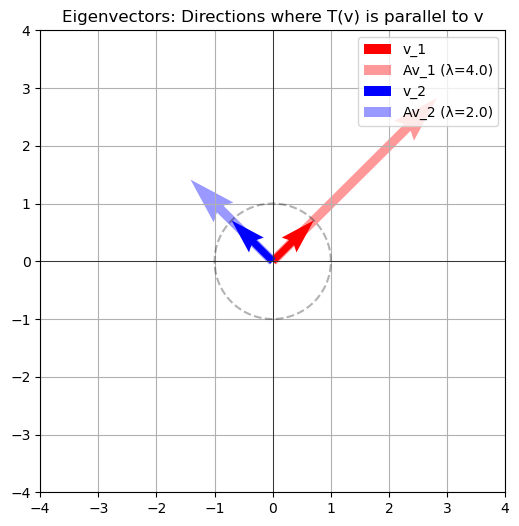

In [ ]:
# 计算特征值并验证 Ax = λx
import torch
import matplotlib.pyplot as plt

def eigen_analysis():
    # 1. 定义一个对称矩阵 (保证特征值为实数，方便可视化)
    A = torch.tensor([[3.0, 1.0],
                      [1.0, 3.0]])

    # 2. 计算特征值和特征向量
    # torch.linalg.eig 通常返回复数，即使结果是实数
    eigvals, eigvecs = torch.linalg.eig(A)

    # 提取实部用于可视化
    eigvals = eigvals.real
    eigvecs = eigvecs.real

    print("特征值 (Eigenvalues):", eigvals)
    print("特征向量 (Eigenvectors):\n", eigvecs)

    # 3. 可视化验证
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 绘制单位圆（参考背景）
    theta = torch.linspace(0, 2*torch.pi, 100)
    ax.plot(torch.cos(theta), torch.sin(theta), 'k--', alpha=0.3)

    colors = ['r', 'b']
    for i in range(2):
        v = eigvecs[:, i]      # 第 i 个特征向量
        Av = A @ v             # 变换后的向量
        lambda_val = eigvals[i]
        
        # 绘制原始特征向量 v
        # 用较细的线宽和完全不透明的颜色
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, 
                  color=colors[i], width=0.015, label=f'v_{i+1}')
        
        # 绘制变换后的向量 Av
        # 使用半透明 (alpha=0.4) 和较粗的线宽来覆盖前者，以示区别
        ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1, 
                  color=colors[i], alpha=0.4, width=0.02, label=f'Av_{i+1} (λ={lambda_val:.1f})')

        # 数值验证
        check = torch.allclose(Av, lambda_val * v, atol=1e-5)
        print(f"向量 {i+1} 验证 Ax == λx: {check}")

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid()
    ax.legend()
    plt.title("Eigenvectors: Directions where T(v) is parallel to v")
    plt.show()

eigen_analysis()

## 5.4 凯莱-哈密顿定理 (Cayley-Hamilton Theorem)
定理断言：每个矩阵都满足其自身的特征方程 $p(A)=O$。这意味着高次幂 $A^n$ 可以被降阶。

### Faddeev-LeVerrier 算法与定理验证
PyTorch 没有直接计算特征多项式系数的函数，我们参考书中的提示，实现 Faddeev-LeVerrier 算法来获取系数，并验证 $p(A)=0$。

In [ ]:
# 构造特征多项式并验证凯莱-哈密顿定理
import torch

def verify_cayley_hamilton():
    torch.manual_seed(123)
    n = 4
    A = torch.randn(n, n) # 生成一个 4x4 随机矩阵

    # 1. 使用 Faddeev-LeVerrier 算法计算特征多项式系数
    # p(λ) = λ^n + c_{n-1}λ^{n-1} + ... + c_1λ + c_0
    
    # 初始化时使用 torch.tensor(1.0)，确保列表中全是 Tensor 类型，
    # 避免后续调用 .item() 时对 float 类型报错。
    poly_coeffs = [torch.tensor(1.0)] 
    
    I = torch.eye(n)
    
    # 算法初始化
    # M_temp 用于存储辅助矩阵 M_k
    M_temp = torch.eye(n)
    
    # 迭代计算系数 c_{n-1} 到 c_0
    for k in range(1, n + 1):
        # M_k = A * M_{k-1}
        AM = A @ M_temp
        
        # c_{n-k} = -1/k * trace(AM)
        c = -torch.trace(AM) / k
        poly_coeffs.append(c)
        
        # M_k (new) = AM + cI
        M_temp = AM + c * I

    # poly_coeffs 全是 Tensor，可以安全调用 .item()
    print(f"特征多项式系数 (高次到低次): \n{[f'{x.item():.2f}' for x in poly_coeffs]}")

    # 2. 计算矩阵多项式 p(A) = A^n + c_{n-1}A^{n-1} + ... + c_0 I
    pA = torch.zeros_like(A)
    
    # 倒序遍历系数来构建 p(A)
    # poly_coeffs[0]对应 A^n, poly_coeffs[n]对应 c_0 * I
    for power, coeff in enumerate(poly_coeffs):
        exponent = n - power
        term = coeff * torch.linalg.matrix_power(A, exponent)
        pA += term

    # 3. 验证结果是否为零矩阵
    norm_pA = torch.norm(pA).item()
    print(f"\n||p(A)|| (Frobenius Norm): {norm_pA}")
    print(f"Is Zero Matrix? {torch.allclose(pA, torch.zeros_like(A), atol=1e-4)}")

verify_cayley_hamilton()

特征多项式系数 (高次到低次): 
['1.00', '-1.97', '2.93', '-2.55', '0.00']

||p(A)|| (Frobenius Norm): 6.958320000194362e-07
Is Zero Matrix? True


## 5.5 对角化与若尔当标准型
对角化是将复杂系统解耦的终极手段。若矩阵可对角化，计算其幂次 $A^k$ 将变得异常简单。反之，如果矩阵“亏损”（如剪切矩阵），则无法对角化。

### 对角化 vs 直接幂运算 vs 亏损矩阵

In [ ]:
# 对角化的威力与局限性
import torch
import torch.linalg as LA

def diagonalization_demo():
    torch.manual_seed(42)

    # === Case 1: 可对角化矩阵 ===
    print("--- Case 1: Diagonalizable Matrix ---")
    A = torch.tensor([[4.0, 2.0],
                      [1.0, 3.0]])
    
    # 特征分解 A = P D P^{-1}
    vals, vecs = LA.eig(A)
    P = vecs
    D = torch.diag(vals)
    P_inv = LA.inv(P)
    
    # 计算 A^10
    # 方法 A: 直接乘
    A_pow_direct = LA.matrix_power(A.to(torch.complex64), 10)
    
    # 方法 B: 对角化 (P * D^10 * P^-1)
    # D^10 只是对角线元素的幂，计算复杂度极低
    D_pow = torch.diag(vals ** 10)
    A_pow_diag = P @ D_pow @ P_inv
    
    diff = torch.norm(A_pow_direct - A_pow_diag).item()
    print(f"||A^10 (Direct) - A^10 (Diagonalized)||: {diff:.2e}")
    
    # === Case 2: 不可对角化矩阵 (剪切矩阵) ===
    print("\n--- Case 2: Defective Matrix (Shear) ---")
    S = torch.tensor([[1.0, 1.0],
                      [0.0, 1.0]])
    
    vals_s, vecs_s = LA.eig(S)
    
    # 检查特征向量矩阵的秩
    rank_P = LA.matrix_rank(vecs_s)
    n = S.shape[0]
    
    print(f"Shear Matrix:\n{S}")
    print(f"Eigenvalues: {vals_s}")
    print(f"Rank of Eigenvector Matrix: {rank_P}")
    print(f"Dimension n: {n}")
    
    if rank_P < n:
        print("结论: 几何重数 < 代数重数，矩阵不可对角化 (Defective)。")
    else:
        print("结论: 矩阵可对角化。")

diagonalization_demo()

--- Case 1: Diagonalizable Matrix ---
||A^10 (Direct) - A^10 (Diagonalized)||: 1.37e+00

--- Case 2: Defective Matrix (Shear) ---
Shear Matrix:
tensor([[1., 1.],
        [0., 1.]])
Eigenvalues: tensor([1.+0.j, 1.+0.j])
Rank of Eigenvector Matrix: 1
Dimension n: 2
结论: 几何重数 < 代数重数，矩阵不可对角化 (Defective)。


### 特征向量的动力学意义——幂迭代法
这个代码块对应书中的“几何直观：主轴方向”以及“对角化计算 $A^{100}$”。我们将展示：如果你不断地对一个向量做线性变换，它最终会“身不由己”地指向最大特征值对应的方向。这是 Google PageRank 算法背后的核心原理，也是理解线性变换“长期行为”的关键。

真实主特征值: 4.00
真实主特征向量: [0.70710677 0.70710677]

--- 开始迭代 (Power Iteration) ---
Iter 1: Cos Similarity with dominant vec = 0.9920
Iter 2: Cos Similarity with dominant vec = 0.9980
Iter 3: Cos Similarity with dominant vec = 0.9995
Iter 4: Cos Similarity with dominant vec = 0.9999
Iter 5: Cos Similarity with dominant vec = 1.0000
Iter 6: Cos Similarity with dominant vec = 1.0000
Iter 7: Cos Similarity with dominant vec = 1.0000
Iter 8: Cos Similarity with dominant vec = 1.0000
Iter 9: Cos Similarity with dominant vec = 1.0000
Iter 10: Cos Similarity with dominant vec = 1.0000


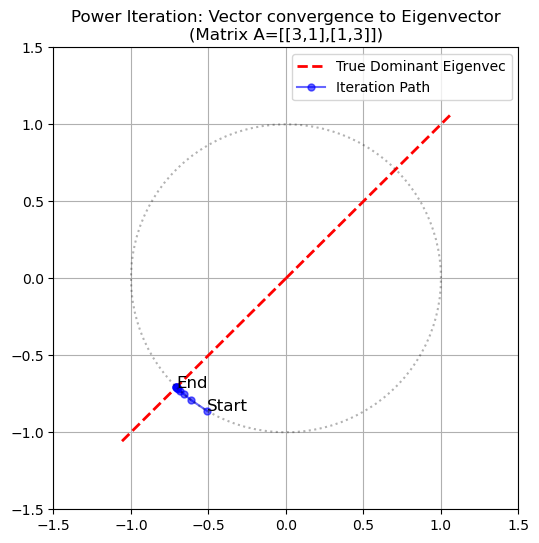

这张图非常直观地展示了线性变换的动力学本质：矩阵就像一台引力机器。不管你从哪里出发（Start），只要你不断地被矩阵作用（乘法迭代），你最终都会身不由己地归顺于那个力量最强的方向——主特征向量的方向。


In [13]:
# 幂迭代法：动态演示向量如何收敛到主特征方向
import torch
import matplotlib.pyplot as plt

def power_iteration_demo():
    torch.manual_seed(10)
    
    # 1. 定义一个具有明显主特征值的矩阵
    # 特征值约为 4 和 2
    A = torch.tensor([[3.0, 1.0],
                      [1.0, 3.0]])
    
    # 先计算出真实的特征向量作为“标准答案”
    vals, vecs = torch.linalg.eig(A)
    vals = vals.real
    vecs = vecs.real
    
    # 找到最大特征值对应的索引
    max_idx = torch.argmax(torch.abs(vals))
    v_dominant = vecs[:, max_idx]
    lambda_dominant = vals[max_idx]
    
    print(f"真实主特征值: {lambda_dominant.item():.2f}")
    print(f"真实主特征向量: {v_dominant.numpy()}")

    # 2. 随机初始化一个向量 x
    x = torch.randn(2)
    x = x / torch.norm(x) # 归一化
    
    # 3. 迭代过程：x_{k+1} = A x_k
    iterations = 10
    history = [x.clone()]
    
    print("\n--- 开始迭代 (Power Iteration) ---")
    for k in range(iterations):
        # 线性变换
        x_new = A @ x
        
        # 归一化 (为了防止数值爆炸，且只关心方向)
        x_new = x_new / torch.norm(x_new)
        
        # 记录轨迹
        history.append(x_new)
        
        # 检查与主特征向量的夹角余弦值
        cos_sim = torch.dot(x_new, v_dominant).abs().item()
        print(f"Iter {k+1}: Cos Similarity with dominant vec = {cos_sim:.4f}")
        
        x = x_new

    # 4. 可视化轨迹
    history = torch.stack(history) # (iters+1, 2)
    
    plt.figure(figsize=(6, 6))
    
    # 画出真实的主特征向量 (红色虚线)
    # 延长一点以便观察
    plt.plot([0, v_dominant[0]*1.5], [0, v_dominant[1]*1.5], 'r--', linewidth=2, label='True Dominant Eigenvec')
    plt.plot([0, -v_dominant[0]*1.5], [0, -v_dominant[1]*1.5], 'r--', linewidth=2)
    
    # 画出迭代轨迹 (蓝色点和连线)
    plt.plot(history[:, 0], history[:, 1], 'bo-', alpha=0.6, markersize=5, label='Iteration Path')
    
    # 标记起点
    plt.text(history[0, 0], history[0, 1], 'Start', fontsize=12)
    # 标记终点
    plt.text(history[-1, 0], history[-1, 1], 'End', fontsize=12)

    # 画单位圆
    theta = torch.linspace(0, 2*torch.pi, 100)
    plt.plot(torch.cos(theta), torch.sin(theta), 'k:', alpha=0.3)
    
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.title(f"Power Iteration: Vector convergence to Eigenvector\n(Matrix A=[[3,1],[1,3]])")
    plt.show()
    
    print("这张图非常直观地展示了线性变换的动力学本质：矩阵就像一台引力机器。不管你从哪里出发（Start），只要你不断地被矩阵作用（乘法迭代），你最终都会身不由己地归顺于那个力量最强的方向——主特征向量的方向。")

power_iteration_demo()